# Linear Regression for predicting gold price

In [40]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
usd_inr = yf.download('USDINR=X',start='2024-01-01',end='2024-12-31',interval='1wk')


[*********************100%***********************]  1 of 1 completed


In [42]:
usd_inr.head()

Price,Close,High,Low,Open,Volume
Ticker,USDINR=X,USDINR=X,USDINR=X,USDINR=X,USDINR=X
Date,,,,,
2024-01-01,83.240601,83.360298,83.035004,83.248596,0
2024-01-08,83.076103,83.189697,82.779099,83.191101,0
2024-01-15,83.160599,83.230797,82.809998,82.872101,0
2024-01-22,83.146103,83.222504,81.513702,83.124702,0
2024-01-29,82.927597,83.212601,82.815002,83.121300,0


In [43]:
usd_inr.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53 entries, 2024-01-01 to 2024-12-30
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, USDINR=X)   53 non-null     float64
 1   (High, USDINR=X)    53 non-null     float64
 2   (Low, USDINR=X)     53 non-null     float64
 3   (Open, USDINR=X)    53 non-null     float64
 4   (Volume, USDINR=X)  53 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 2.5 KB


In [44]:
usd_inr.reset_index(inplace=True)

In [45]:
usd_inr.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,USDINR=X,USDINR=X,USDINR=X,USDINR=X,USDINR=X
0,2024-01-01,83.240601,83.360298,83.035004,83.248596,0
1,2024-01-08,83.076103,83.189697,82.779099,83.191101,0
2,2024-01-15,83.160599,83.230797,82.809998,82.872101,0
3,2024-01-22,83.146103,83.222504,81.513702,83.124702,0
4,2024-01-29,82.927597,83.212601,82.815002,83.121300,0


In [46]:
df=usd_inr[['Date','Close']]
df.columns =['Date','USD_INR']
df.head()

,Date,USD_INR
0,2024-01-01,83.240601
1,2024-01-08,83.076103
2,2024-01-15,83.160599
3,2024-01-22,83.146103
4,2024-01-29,82.927597


In [48]:
gold_df = pd.read_csv('datasets/Gold vs USDINR.csv')
gold_df.head()

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,"₹5,066.31"
1,2024-01-08,83.076103,"₹4,966.31"
2,2024-01-15,83.160599,"₹5,015.33"
3,2024-01-22,83.146103,"₹4,950.84"
4,2024-01-29,82.927597,"₹4,976.77"


In [49]:
gold_df['Goldrate'] = gold_df['Goldrate'].replace('₹','',regex=True).replace(',','',regex=True).astype(float)


In [50]:
gold_df.head()

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,5066.31
1,2024-01-08,83.076103,4966.31
2,2024-01-15,83.160599,5015.33
3,2024-01-22,83.146103,4950.84
4,2024-01-29,82.927597,4976.77


In [51]:
gold_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      53 non-null     object 
 1   USD_INR   53 non-null     float64
 2   Goldrate  53 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.4+ KB


# EDA

In [52]:
# Handle Missing Values - No
# Handle Imbalanced Dataset - No 
# Handle Outliers -  Seen
# Encode Categorical Features - No
# Normalization vs Standardization - Standardization 


Text(0.5, 1.0, 'Outliers in USD INR Rate')

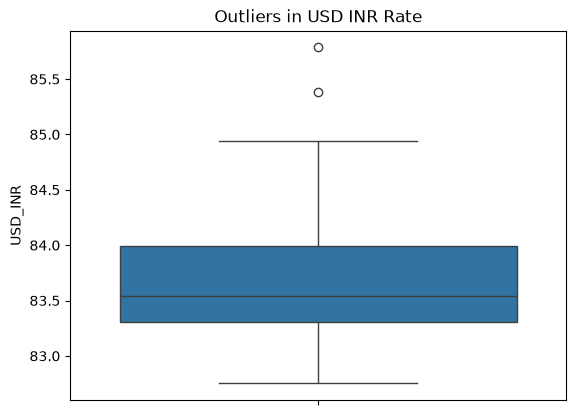

In [53]:
sns.boxplot(gold_df['USD_INR'])
plt.title("Outliers in USD INR Rate")

In [54]:
gold_df['USD_INR'].max()

np.float64(85.78659821)

<Axes: xlabel='USD_INR', ylabel='Goldrate'>

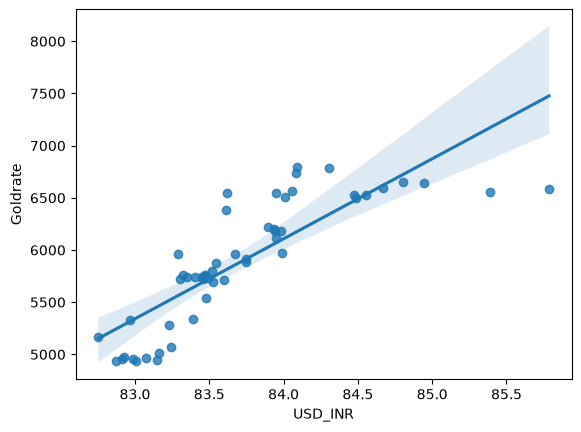

In [55]:
sns.regplot(x ='USD_INR', y= 'Goldrate',data=gold_df)